#### Data processing

In [1]:
# Transform structure.xyz into dpdata.System via ASE
import dpdata
from ase import Atoms
from ase.io import read
import numpy as np

# Step 1: Read XYZ file using ASE
xyz_file = "../data/train.xyz"
atoms_list = read(xyz_file, index=':')  # Read all frames

print(f"Number of frames loaded: {len(atoms_list)}")
print(f"First frame has {len(atoms_list[0])} atoms")
print(f"Chemical symbols in first frame: {list(set(atoms_list[0].get_chemical_symbols()))}")

# Step 2: Set PBC for all atoms if needed
for atoms in atoms_list:
    atoms.set_pbc(True)  # Set periodic boundary conditions

# Step 3: Manually extract data from ASE atoms and create dpdata.System
# Define type_map for consistent element ordering
type_map = ["H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
           "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
           "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
           "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr",
           "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
           "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd",
           "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb",
           "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg",
           "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th",
           "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm",
           "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds",
           "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og"]

# Extract data manually from ASE atoms
nframes = len(atoms_list)
natoms = len(atoms_list[0])

# Get unique chemical symbols and create atom_types mapping
all_symbols = set()
for atoms in atoms_list:
    all_symbols.update(atoms.get_chemical_symbols())

# Create atom_names list (unique elements in the system)
atom_names = sorted(list(all_symbols))
print(f"Elements in system: {atom_names}")

# Create atom_types array (maps each atom to its element type)
atom_types = []
for symbol in atoms_list[0].get_chemical_symbols():
    atom_types.append(atom_names.index(symbol))
atom_types = np.array(atom_types, dtype=int)

# Extract coordinates and cells
coords = []
cells = []
for atoms in atoms_list:
    coords.append(atoms.get_positions())
    cells.append(atoms.get_cell().array)

coords = np.array(coords)  # Shape: (nframes, natoms, 3)
cells = np.array(cells)    # Shape: (nframes, 3, 3)
print(cells[0])
print(f"Extracted data shapes:")
print(f"  coords: {coords.shape}")
print(f"  cells: {cells.shape}")
print(f"  atom_types: {atom_types.shape}")
print(f"  atom_names: {atom_names}")

# Create dpdata.System manually
sys = dpdata.System()
sys.data = {
    'atom_names': atom_names,
    'atom_numbs': [np.sum(atom_types == i) for i in range(len(atom_names))],
    'atom_types': atom_types,
    'coords': coords,
    'cells': cells,
    'orig': np.zeros(3),  # Origin point
    'nopbc': False  # Has periodic boundary conditions
}
#ms=dpdata.MultiSystems()
#ms.append(sys)
#ms.to_deepmd_npy_mixed("train")
sys.to('deepmd/npy', 'train')

Number of frames loaded: 2500
First frame has 167 atoms
Chemical symbols in first frame: ['H', 'C', 'Cu', 'O', 'K']
Elements in system: ['C', 'Cu', 'H', 'K', 'O']
[[10.16868  0.       0.     ]
 [ 0.      10.16868  0.     ]
 [ 0.       0.      35.     ]]
Extracted data shapes:
  coords: (2500, 167, 3)
  cells: (2500, 3, 3)
  atom_types: (167,)
  atom_names: ['C', 'Cu', 'H', 'K', 'O']


In [ ]:
# then generate properties
# extensive
import numpy as np
cpzc = np.loadtxt('../data/CPZC_train.txt')
epzc = np.loadtxt('../data/EPZC_train.txt')

extensive = np.column_stack((cpzc.flatten(), epzc.flatten()))

print(f"CPZC shape: {cpzc.shape}")
print(f"EPZC shape: {epzc.shape}")
print(f"Extensive shape: {extensive.shape}")

np.save('./train/set.000/extensive.npy', extensive)


# intensive
upzc = np.loadtxt('../data/UPZC_train.txt')
np.save('./train/set.000/intensive.npy', upzc)

CPZC shape: (2500,)
EPZC shape: (2500,)
Extensive shape: (2500, 2)


In [18]:
import dpdata
from ase import Atoms
from typing import List
from ase.io import read

def ase2dpdata(
    atoms: Atoms,
    labeled: bool = False,
    ) -> dpdata.System:
    """[Modified from dpdata.plugins.ase] Convert ase.Atoms to dpdata System.
    
    Parameters
    ----------
    atoms : ase.Atoms
        The ase.Atoms object to convert.
    labeled : bool, optional
        Whether the atoms object has labels (forces, energies, virials), by default False
    
    """
    symbols = atoms.get_chemical_symbols()
    atom_names = list(dict.fromkeys(symbols))
    atom_numbs = [symbols.count(symbol) for symbol in atom_names]
    atom_types = np.array([atom_names.index(symbol) for symbol in symbols]).astype(
            int
        )
    cells = atoms.cell.array
    coords = atoms.get_positions()
    info_dict = {
            "atom_names": atom_names,
            "atom_numbs": atom_numbs,
            "atom_types": atom_types,
            "cells": np.array([cells]),
            "coords": np.array([coords]),
            "orig": np.zeros(3),
            "nopbc": not np.any(atoms.get_pbc()),
        }
    if labeled:
        energy = atoms.get_potential_energy()
        info_dict["energies"] = np.array([energy])
        
        forces = atoms.get_forces()
        info_dict["forces"] = np.array([forces])

        if "virial" in atoms.arrays:
            virials = atoms.arrays["virial"]
            info_dict["virial"] = np.array([virials])
        return dpdata.LabeledSystem.from_dict({'data':info_dict})
    return dpdata.System.from_dict({'data':info_dict})

def ase2multisys(
    atoms_list: List[Atoms],
    labeled: bool = False,
    ) -> dpdata.MultiSystems:
    """Convert list of ase.Atoms to dpdata MultiSystem."""
    ms=dpdata.MultiSystems()
    for atoms in atoms_list:
        system = ase2dpdata(atoms, labeled=labeled)
        ms.append(system)
    return ms

atoms_lst = read("../data/test.xyz", index=':')
ms = ase2multisys(atoms_lst, labeled=False)
ms.to_deepmd_npy("data/test")

MultiSystems (1 systems containing 100 frames)

In [30]:
## infer intensive properties
from deepmd.pt.infer.deep_eval import DeepProperty
import dpdata

dp = DeepProperty(
    "/home/ruoyu/project/property/dpa2/model.ckpt.pt",
    head="intensive",
    task_dim=2,
    )

type_map=[ "H","He",
      "Li",
      "Be",
      "B",
      "C",
      "N",
      "O",
      "F",
      "Ne",
      "Na",
      "Mg",
      "Al",
      "Si",
      "P",
      "S",
      "Cl",
      "Ar",
      "K",
      "Ca",
      "Sc",
      "Ti",
      "V",
      "Cr",
      "Mn",
      "Fe",
      "Co",
      "Ni",
      "Cu",
      "Zn",
      "Ga",
      "Ge",
      "As",
      "Se",
      "Br",
      "Kr",
      "Rb",
      "Sr",
      "Y",
      "Zr",
      "Nb",
      "Mo",
      "Tc",
      "Ru",
      "Rh",
      "Pd",
      "Ag",
      "Cd",
      "In",
      "Sn",
      "Sb",
      "Te",
      "I",
      "Xe",
      "Cs",
      "Ba",
      "La",
      "Ce",
      "Pr",
      "Nd",
      "Pm",
      "Sm",
      "Eu",
      "Gd",
      "Tb",
      "Dy",
      "Ho",
      "Er",
      "Tm",
      "Yb",
      "Lu",
      "Hf",
      "Ta",
      "W",
      "Re",
      "Os",
      "Ir",
      "Pt",
      "Au",
      "Hg",
      "Tl",
      "Pb",
      "Bi",
      "Po",
      "At",
      "Rn",
      "Fr",
      "Ra",
      "Ac",
      "Th",
      "Pa",
      "U",
      "Np",
      "Pu",
      "Am",
      "Cm",
      "Bk",
      "Cf",
      "Es",
      "Fm",
      "Md",
      "No",
      "Lr",
      "Rf",
      "Db",
      "Sg",
      "Bh",
      "Hs",
      "Mt",
      "Ds",
      "Rg",
      "Cn",
      "Nh",
      "Fl",
      "Mc",
      "Lv",
      "Ts",
      "Og"
    ]


data = dpdata.System("../data/test/H60C1O32K2Cu72", fmt='deepmd/npy')
data.get_nframes()

res=dp.eval(
    data.data['coords'],
    None,#data.data['cells'][:1],
    data.get_atom_types(),
    atomic=True,
    )

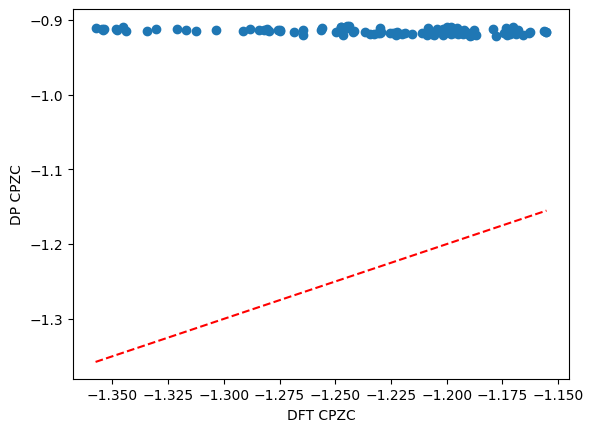

In [31]:
# test
import matplotlib.pyplot as plt
import numpy as np
cpzc_data=np.loadtxt('../data/CPZC_test.txt')
cpzc_pred = res[0]

plt.scatter(cpzc_data, cpzc_pred)
plt.xlabel('DFT CPZC')
plt.ylabel('DP CPZC')
plt.plot([min(cpzc_data), max(cpzc_data)], [min(cpzc_data), max(cpzc_data)], 'r--')
plt.show()


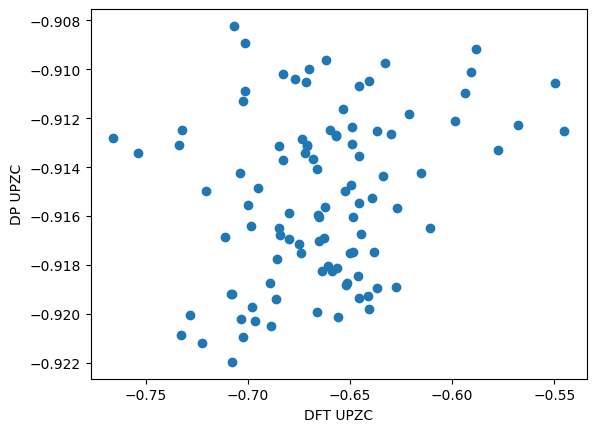

In [32]:
# test
import matplotlib.pyplot as plt
import numpy as np
upzc_data=np.loadtxt('../data/UPZC_test.txt')
upzc_pred = res[0]

plt.scatter(upzc_data, upzc_pred)
plt.xlabel('DFT UPZC')
plt.ylabel('DP UPZC')
#plt.plot([min(cpzc_data), max(cpzc_data)], [min(cpzc_data), max(cpzc_data)], 'r--')
plt.show()
